In [2]:
import pandas as pd

In [3]:
df40 = pd.read_csv("latlons_40.csv")

In [4]:
df42x71 = pd.read_csv ("latlons_42x71.csv")

In [5]:
df42x71.head()

,point,lat,lon
0,0,41.1,-109.0
1,1,41.1,-108.9
2,2,41.1,-108.8
3,3,41.1,-108.7
4,4,41.1,-108.6


In [6]:
df40.head()

,lon,lat
0,-109.0,41.0
1,-108.0,41.0
2,-107.0,41.0
3,-106.0,41.0
4,-105.0,41.0


<Axes: xlabel='lon', ylabel='lat'>

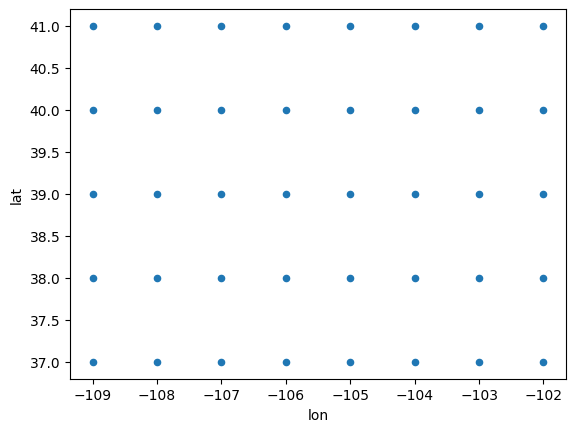

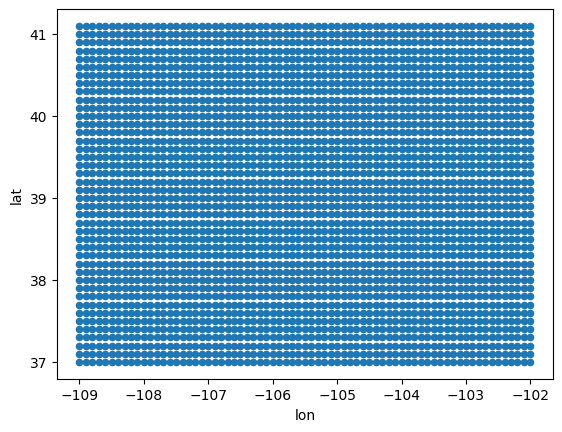

In [9]:
df40.plot(x='lon', y='lat', kind='scatter')
df42x71.plot(x='lon', y='lat', kind='scatter')

In [10]:
df40.head(100)

,lon,lat
0,-109.0,41.0
1,-108.0,41.0
2,-107.0,41.0
3,-106.0,41.0
4,-105.0,41.0
5,-104.0,41.0
6,-103.0,41.0
7,-102.0,41.0
8,-109.0,40.0
9,-108.0,40.0


In [30]:
import numpy as np
import pandas as pd

def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate the great circle distance between two points on Earth (in km)
    """
    # Convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371  # Radius of earth in kilometers
    return c * r

def find_closest_point(df, target_lat, target_lon, lat_col='lat', lon_col='lon'):
    """
    Find the closest point in a DataFrame to a target latitude/longitude
    
    Args:
        df: DataFrame containing latitude and longitude columns
        target_lat: Target latitude
        target_lon: Target longitude
        lat_col: Name of latitude column (default: 'lat')
        lon_col: Name of longitude column (default: 'lon')
    
    Returns:
        Series containing the closest point's data
    """
    # Calculate distances to all points
    distances = df.apply(
        lambda row: haversine_distance(target_lat, target_lon, row[lat_col], row[lon_col]),
        axis=1
    )
    
    # Find index of minimum distance
    closest_idx = distances.idxmin()
    
    return df.loc[closest_idx,['point','lat','lon']], distances[closest_idx]

# Example usage with your data:
target_lat = 41
target_lon = -105.0
lat_lons = [
    [41.0, -109.0,1], [41.0, -105.0,5], [41.0, -102.0,8],
    [39.0, -109.0,17], [39.0, -105.0,21], [39.0, -102.0,24],
    [37.0, -109.0,33], [37.0, -105.0,37], [37.0, -102.0,40]    
            ]

for lat, lon, point in lat_lons:
    closest_point, distance = find_closest_point(df42x71, lat, lon, 'lat', 'lon')
    print(f"Target: ({point},{lat}, {lon}) -> Closest point: {int(closest_point['point']):4d} with distance: {distance:.2f} km") 
# closest_point, distance = find_closest_point(df42x71, target_lat, target_lon, 'lat', 'lon')
# print(f"Closest point: {closest_point}")
# print(f"Distance: {distance:.2f} km")

Target: (1,41.0, -109.0) -> Closest point:   71 with distance: 0.00 km
Target: (5,41.0, -105.0) -> Closest point:  111 with distance: 0.00 km
Target: (8,41.0, -102.0) -> Closest point:  141 with distance: 0.00 km
Target: (17,39.0, -109.0) -> Closest point: 1491 with distance: 0.00 km
Target: (21,39.0, -105.0) -> Closest point: 1531 with distance: 0.00 km
Target: (24,39.0, -102.0) -> Closest point: 1561 with distance: 0.00 km
Target: (33,37.0, -109.0) -> Closest point: 2911 with distance: 0.00 km
Target: (37,37.0, -105.0) -> Closest point: 2951 with distance: 0.00 km
Target: (40,37.0, -102.0) -> Closest point: 2981 with distance: 0.00 km


In [23]:
closest_point 

point    2981.0
lat        37.0
lon      -102.0
Name: 2981, dtype: float64